# Delay Characterization: Industrial/Experimental Data (Parquet)

**Objective:** Identify and characterize the optimal time lag between two sensor signals from industrial/experimental data using the `DelayCharacterizationPipeline`.

This notebook uses `ParquetDataSource` with the `DelayCharacterizationPipeline` to analyze synchronization between any two columns in a Parquet file. Adapt the column names and time window to your specific dataset.

In [1]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from synch_analysis import (
    ParquetDataSource,
    DelayCharacterizationPipeline,
)

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Publication-quality figure settings
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.grid': False,
    'axes.axisbelow': True,
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.linewidth': 0.8,
    'xtick.major.size': 4,
    'xtick.major.width': 0.8,
    'ytick.major.size': 4,
    'ytick.major.width': 0.8,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': 'black',
    'lines.linewidth': 1.0,
    'lines.markersize': 4
})

## Configuration

Set the Parquet file path, column names, and time window for analysis. The example below uses sensors varA and varB from `datos_ind.pqt`.

In [3]:
# Load data with NO smoothing (window=1) - pipeline handles smoothing
parquet = ParquetDataSource(
     file_path="../data/datos_ind.pqt",
     column_a="VarA",
     column_b="VarB",
     index_start="2021-11-03 12:10:00",
     index_end="2021-11-03 12:30:00",
     window=1,          # No smoothing in data source
     lag=None,
     sampling_rate=1.0,
 )

## Compute Real Lag (Physical Transit Time)

For varA/varB, compute the physical transit time using belt/conveyor distance and velocity.

In [4]:
# Load velocity data for real lag calculation
df = pd.read_parquet("../data/datos_ind.pqt")
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

# Use the same time window as the analysis
df_window = df.loc["2021-11-03 12:10:00":"2021-11-03 12:30:00"]
vel = df_window['Velocidad'].mean()

# Physical transit distance (belt/conveyor)
distance = 18600  # units
real_lag = int(distance / vel)
print(f'Average velocity: {vel:.2f} units/s')
print(f'Real lag (distance/speed): {real_lag}s ({real_lag/60:.1f} min)')

Average velocity: 205.00 units/s
Real lag (distance/speed): 90s (1.5 min)


## Run Delay Characterization Pipeline

The `DelayCharacterizationPipeline` automatically:
1. Loads the data via `ParquetDataSource`
2. Runs Kuramoto lag sweep (phase synchronization)
3. Runs JRP lag sweep (state-space synchronization)
4. Computes combined scores
5. Finds optimal lags from both methods

In [5]:
# Pipeline configuration matching kuramoto_jrp_analysis_varA_varB.ipynb
pipeline = DelayCharacterizationPipeline(
    parquet,
    max_lag=500,           # Search up to 1000 seconds
    lag_step=5,            # 5 second steps
    jrp_m=3,               # Embedding dimension (optimized from working notebook)
    jrp_tau=1,             # Embedding delay
    jrp_rate=0.3,          # Recurrence rate (optimized)
    jrp_smooth_size=10,     # Smoothing window for JRP 
)

# Run the full pipeline
pipeline.run()

Loading data: Parquet: ../data/datos_ind.pqt [VarA vs VarB]
  Signal A: VarA (1199 samples)
  Signal B: VarB (1199 samples)
Running Kuramoto lag sweep (lags: 201)...
Running JRP lag sweep...
Computing combined scores...
  Best Kuramoto lag: 90 steps (90.000 s)
  Best JRP lag: 90 steps (90.000 s)
  Best Combined lag: 90 steps (90.000 s)


## Results Summary

In [6]:
# Summary statistics
results_df = pipeline.get_results()
best_kuramoto = int(results_df.loc[results_df['kuramoto_score'].idxmax(), 'lag'])
best_kuramoto_sustained = results_df.loc[results_df['kuramoto_score'].idxmax(), 'max_sustained_tu']
best_kuramoto_frac = results_df.loc[results_df['kuramoto_score'].idxmax(), 'frac_above_07']
best_kuramoto_r = results_df.loc[results_df['kuramoto_score'].idxmax(), 'r_mean']

jrp_valid = results_df[(results_df['lag'] != -results_df['lag'].max()) & (results_df['lag'] != results_df['lag'].max()) & (results_df['jrp_RR'] > 0)].copy()
best_jrp = int(jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'lag']) if len(jrp_valid) > 0 else 0
best_jrp_rr = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_RR'] if len(jrp_valid) > 0 else 0
best_jrp_det = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_DET'] if len(jrp_valid) > 0 else 0
best_jrp_lam = jrp_valid.loc[jrp_valid['jrp_score'].idxmax(), 'jrp_LAM'] if len(jrp_valid) > 0 else 0

best_combined = int(results_df.loc[results_df['combined_score'].idxmax(), 'lag'])
best_combined_score = results_df.loc[results_df['combined_score'].idxmax(), 'combined_score']

sr = pipeline.signal_pair.sampling_rate
print(f"Best Kuramoto lag: {best_kuramoto} steps ({best_kuramoto/sr:.1f}s) | r_mean: {best_kuramoto_r:.4f} | frac_above_07: {best_kuramoto_frac:.4f} | max_sustained: {best_kuramoto_sustained:.1f}s")
print(f"Best JRP lag: {best_jrp} steps ({best_jrp/sr:.1f}s) | RR: {best_jrp_rr:.4f} | DET: {best_jrp_det:.4f} | LAM: {best_jrp_lam:.4f}")
print(f"Best Combined lag: {best_combined} steps ({best_combined/sr:.1f}s) | Score: {best_combined_score:.4f}")
print(f"Real lag (physical): {real_lag} steps ({real_lag/sr:.1f}s)")

Best Kuramoto lag: 90 steps (90.0s) | r_mean: 0.8377 | frac_above_07: 0.8157 | max_sustained: 74.0s
Best JRP lag: 90 steps (90.0s) | RR: 0.1340 | DET: 0.9860 | LAM: 0.9930
Best Combined lag: 90 steps (90.0s) | Score: 0.9970
Real lag (physical): 90 steps (90.0s)


## Plot Kuramoto Metrics vs Lag

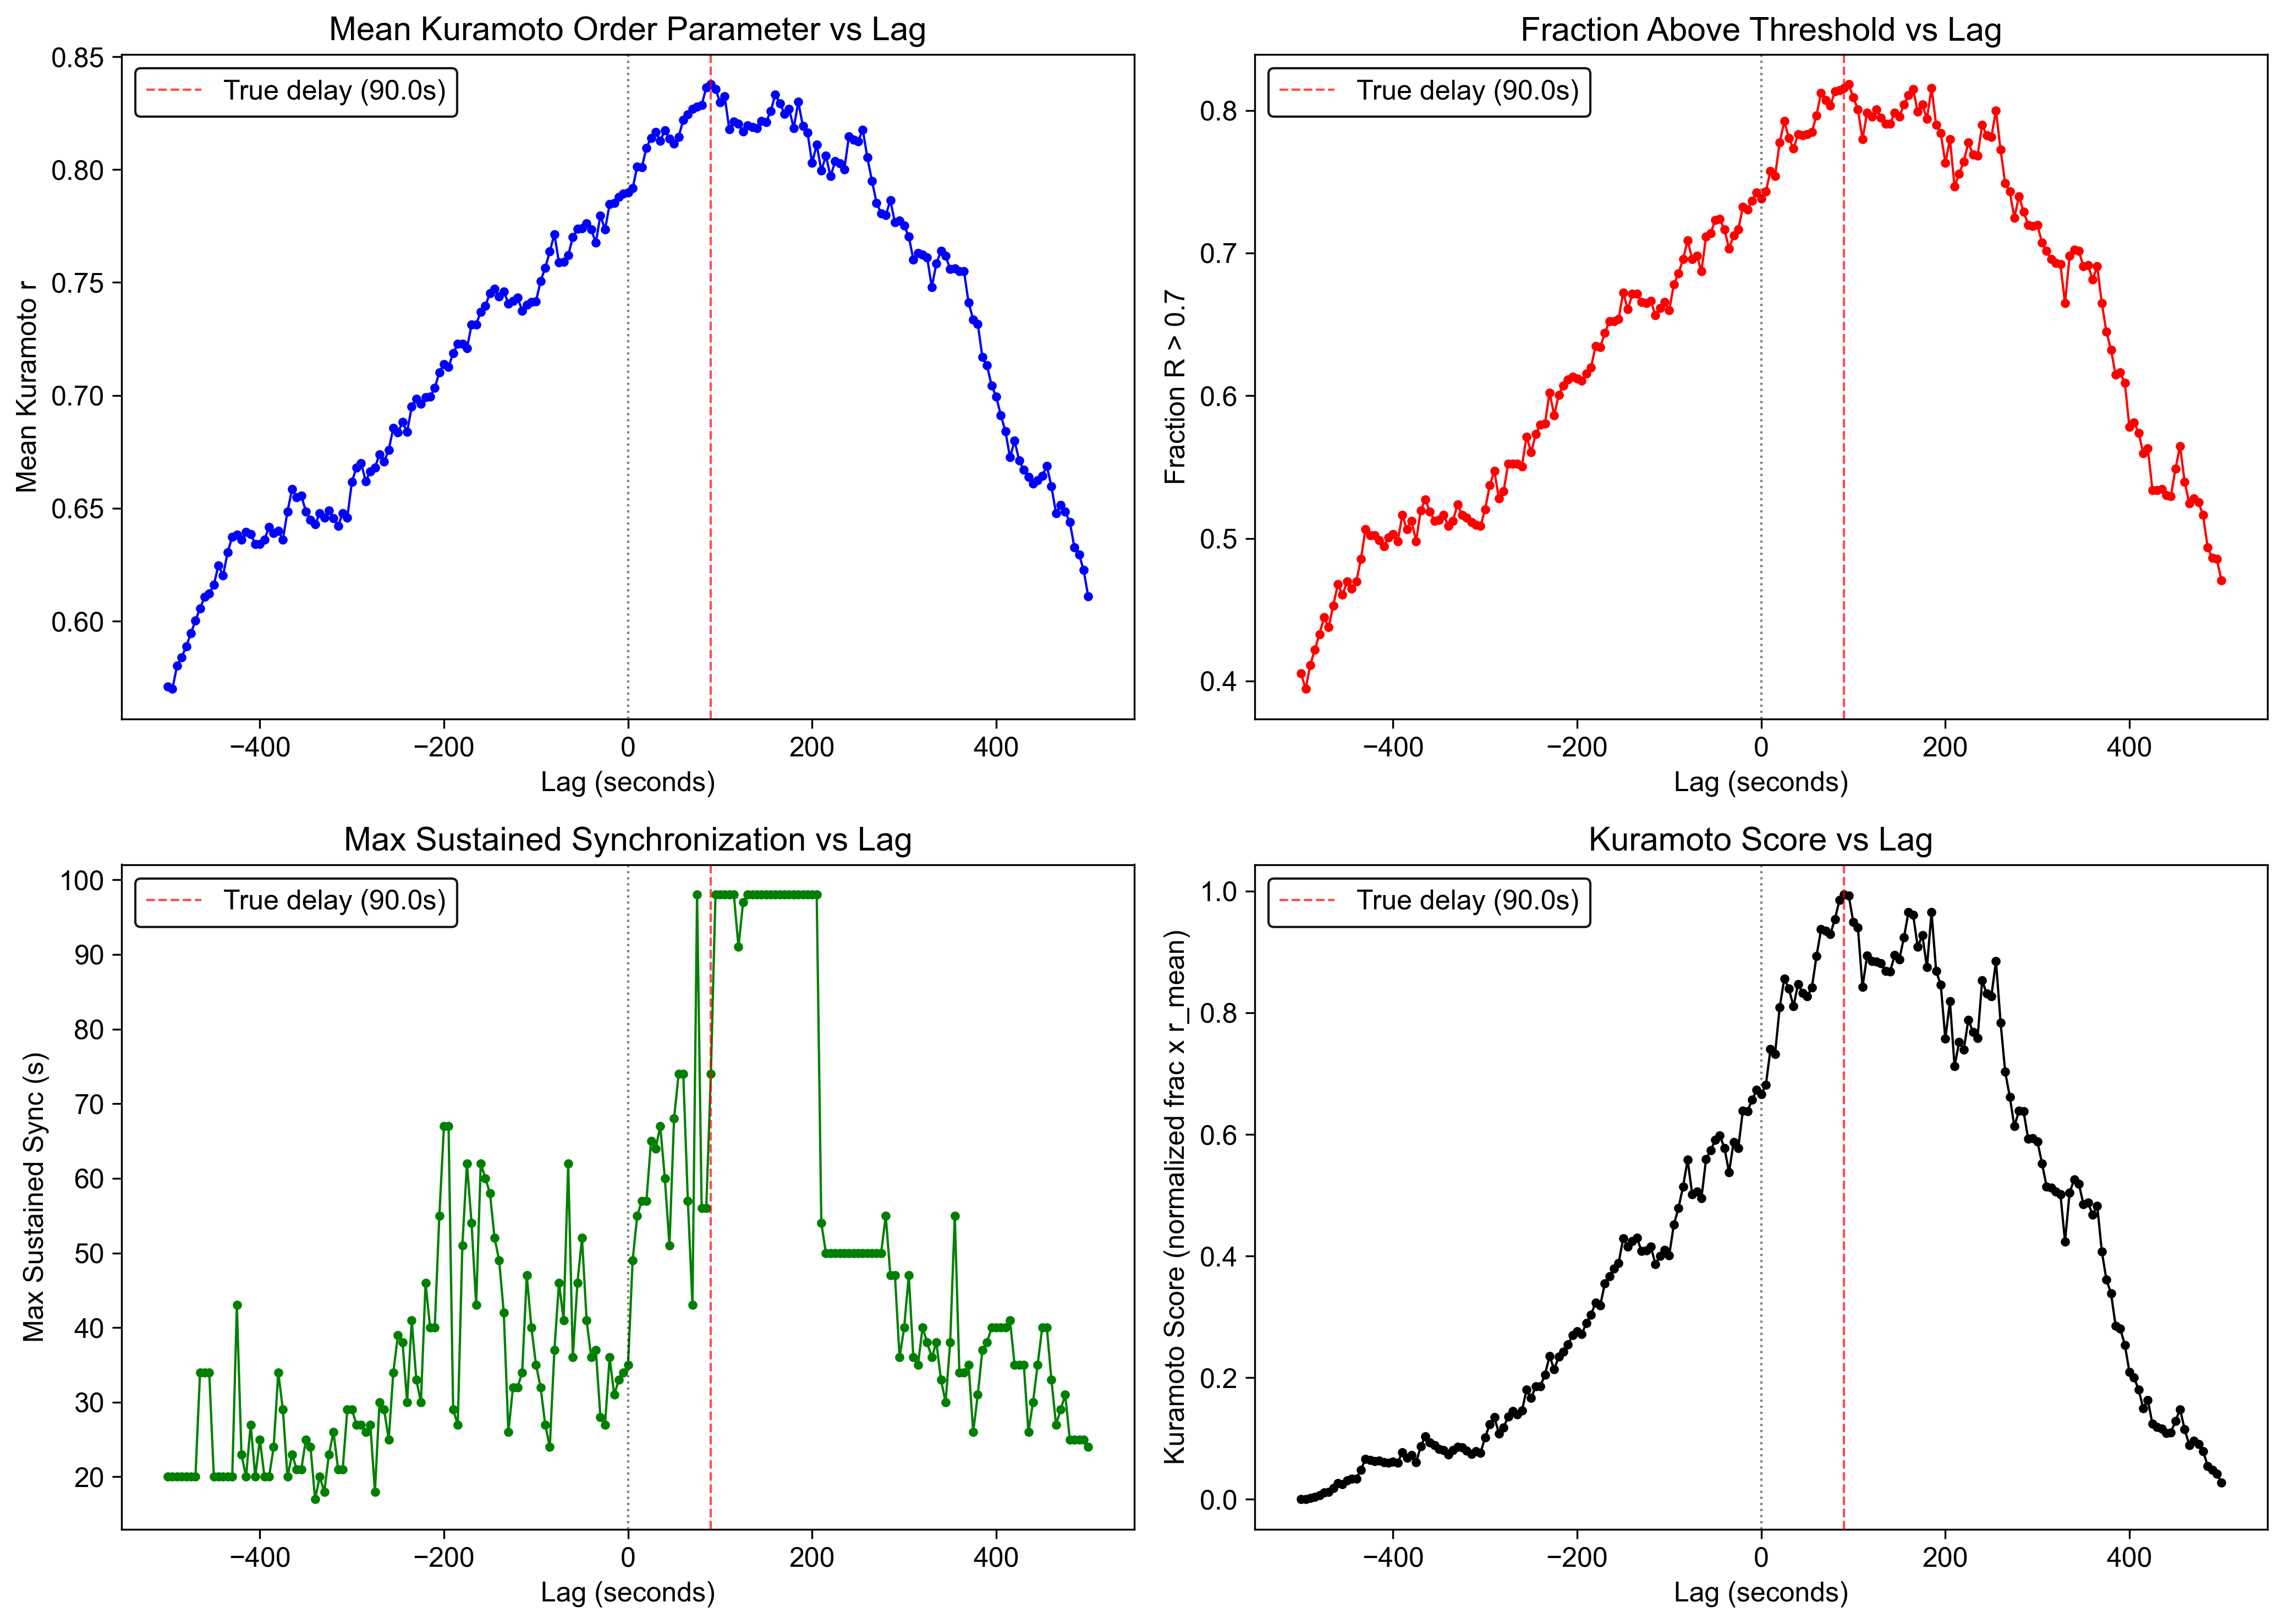

In [7]:
# Plot Kuramoto metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

true_delay_sec = real_lag / sr

axes[0, 0].plot(results_df['lag_tu'], results_df['r_mean'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Mean Kuramoto r')
axes[0, 0].set_title('Mean Kuramoto Order Parameter vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[0, 1].plot(results_df['lag_tu'], results_df['frac_above_07'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Fraction R > 0.7')
axes[0, 1].set_title('Fraction Above Threshold vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 0].plot(results_df['lag_tu'], results_df['max_sustained_tu'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Max Sustained Sync (s)')
axes[1, 0].set_title('Max Sustained Synchronization vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 1].plot(results_df['lag_tu'], results_df['kuramoto_score'], 'k-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('Kuramoto Score (normalized frac x r_mean)')
axes[1, 1].set_title('Kuramoto Score vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Plot JRP Metrics vs Lag

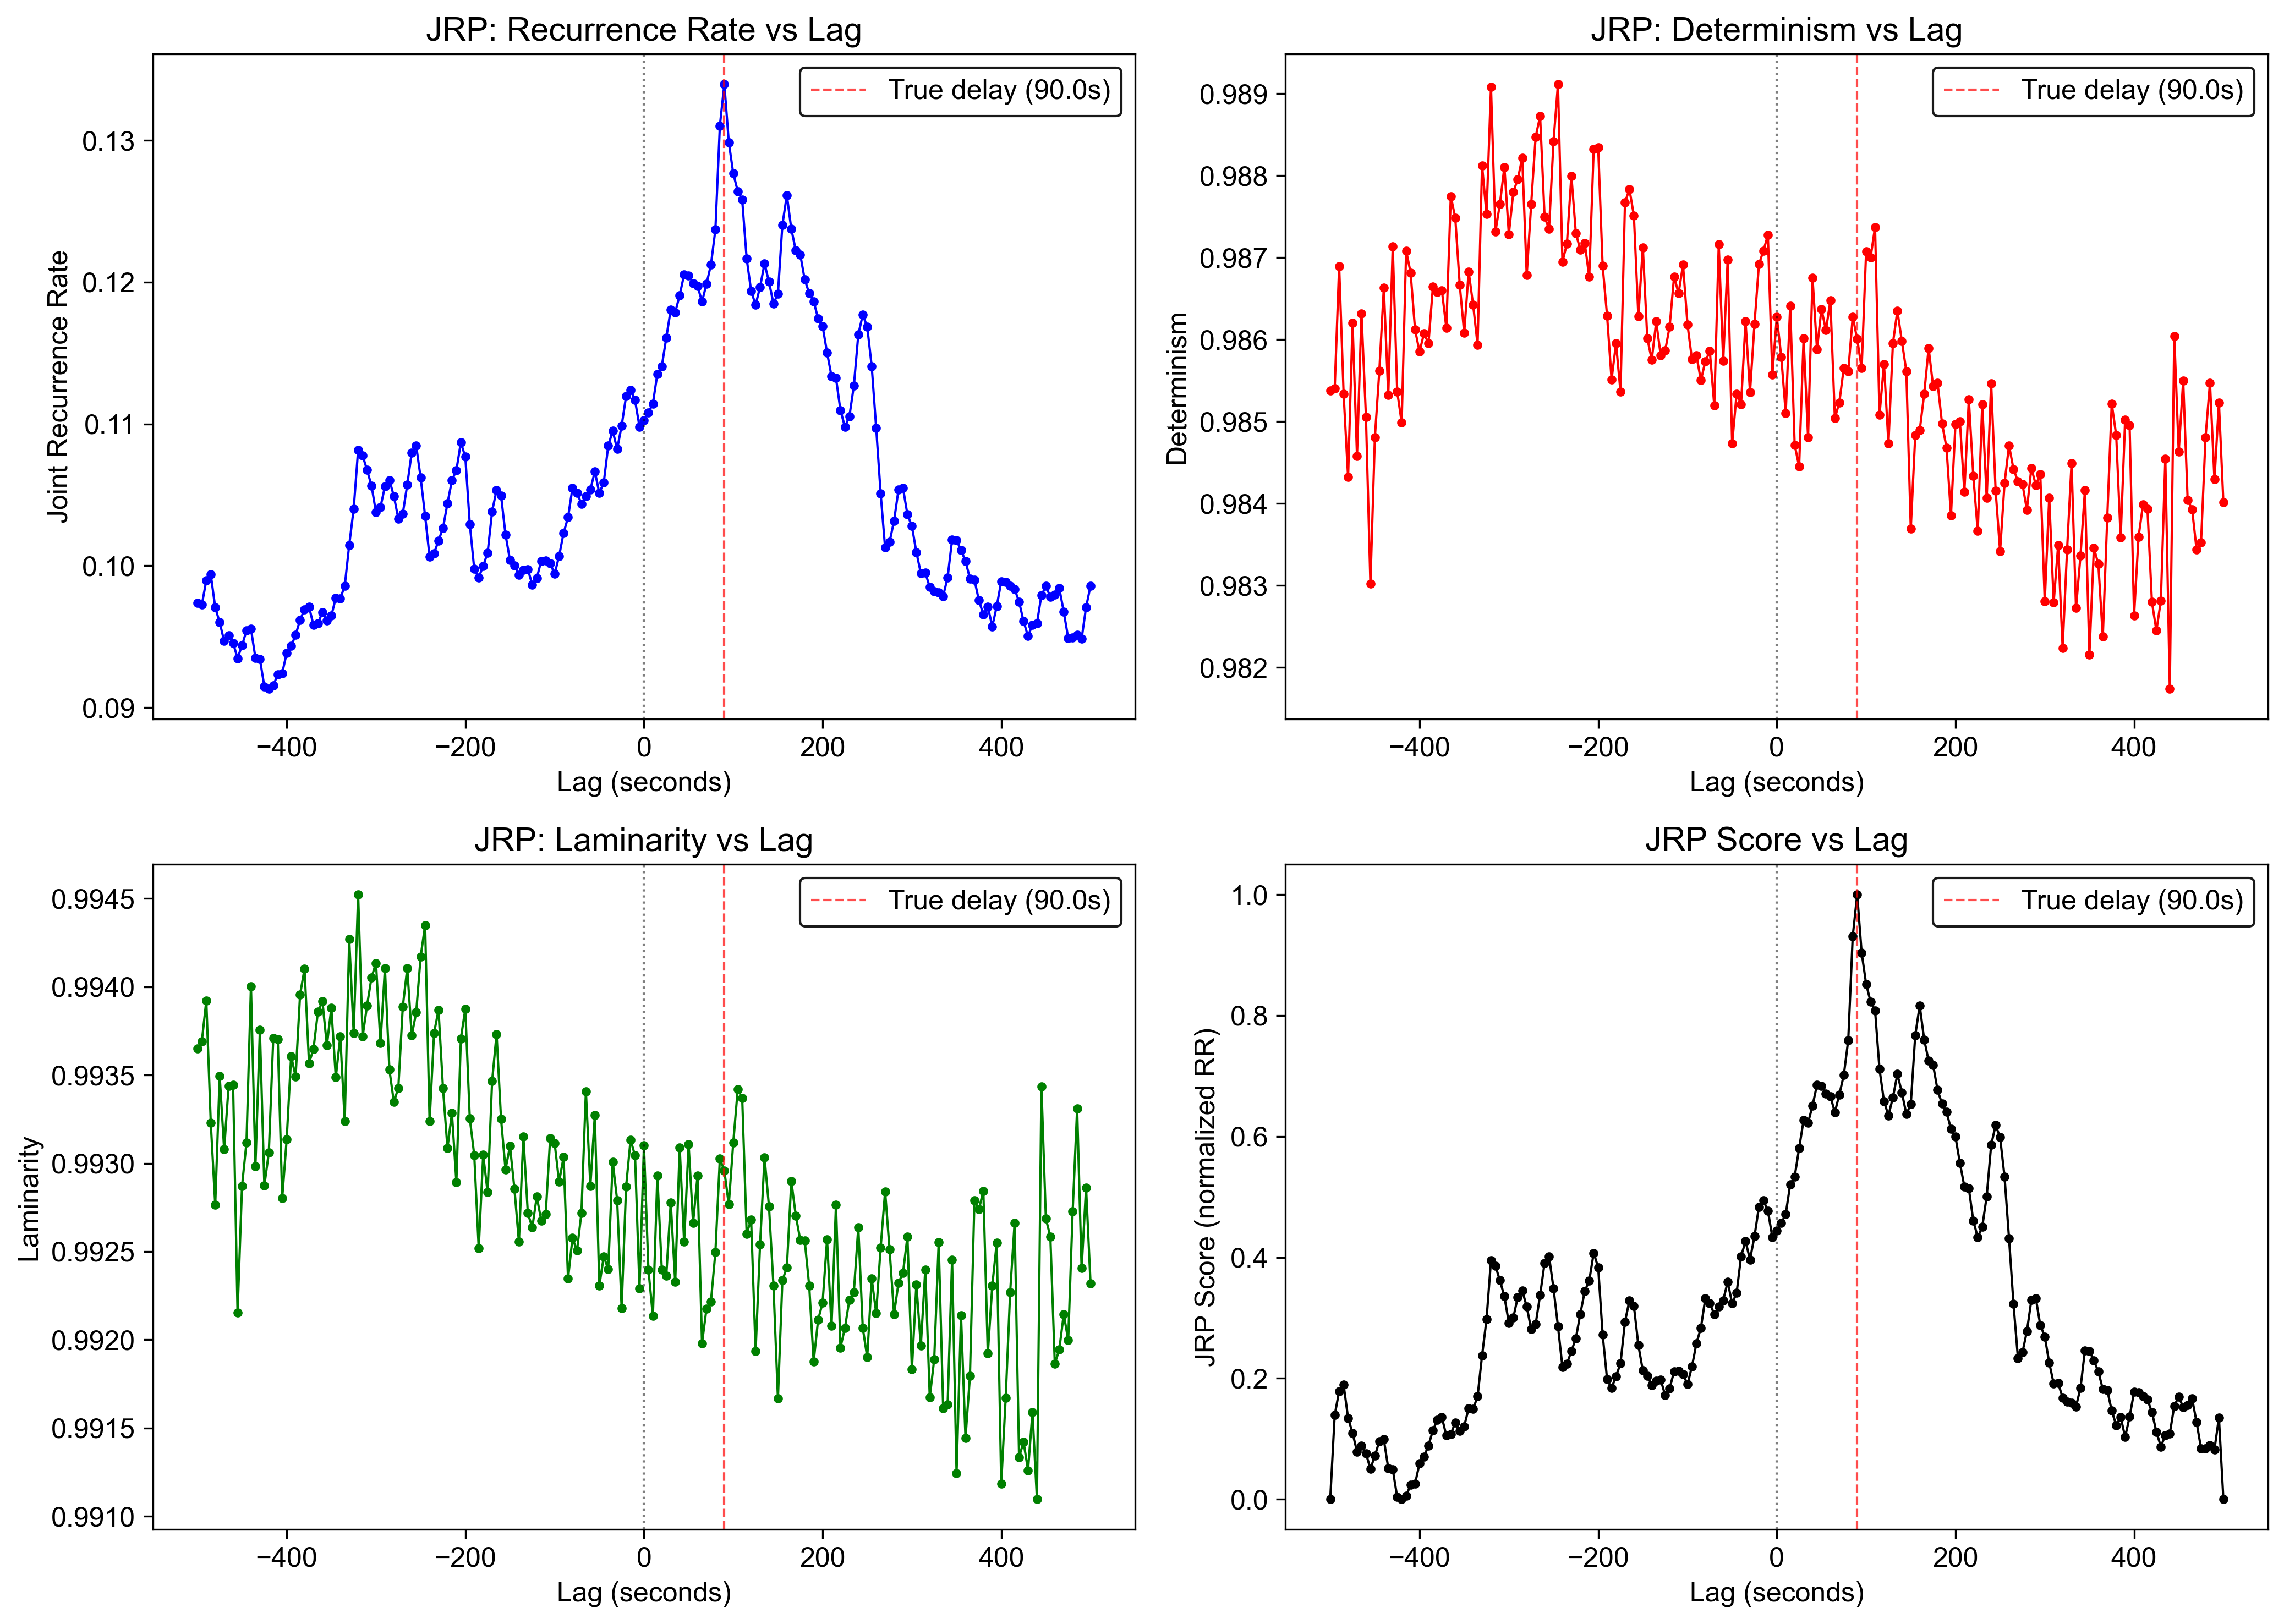

In [8]:
# Plot JRP metrics
jrp_df = results_df[results_df['jrp_RR'] > 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('white')

axes[0, 0].plot(jrp_df['lag_tu'], jrp_df['jrp_RR'], 'b-o', linewidth=1, markersize=3)
axes[0, 0].set_xlabel('Lag (seconds)')
axes[0, 0].set_ylabel('Joint Recurrence Rate')
axes[0, 0].set_title('JRP: Recurrence Rate vs Lag')
axes[0, 0].grid(False)
axes[0, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[0, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[0, 1].plot(jrp_df['lag_tu'], jrp_df['jrp_DET'], 'r-o', linewidth=1, markersize=3)
axes[0, 1].set_xlabel('Lag (seconds)')
axes[0, 1].set_ylabel('Determinism')
axes[0, 1].set_title('JRP: Determinism vs Lag')
axes[0, 1].grid(False)
axes[0, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[0, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 0].plot(jrp_df['lag_tu'], jrp_df['jrp_LAM'], 'g-o', linewidth=1, markersize=3)
axes[1, 0].set_xlabel('Lag (seconds)')
axes[1, 0].set_ylabel('Laminarity')
axes[1, 0].set_title('JRP: Laminarity vs Lag')
axes[1, 0].grid(False)
axes[1, 0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[1, 0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1, 1].plot(jrp_df['lag_tu'], jrp_df['jrp_score'], 'k-o', linewidth=1, markersize=3)
axes[1, 1].set_xlabel('Lag (seconds)')
axes[1, 1].set_ylabel('JRP Score (normalized RR)')
axes[1, 1].set_title('JRP Score vs Lag')
axes[1, 1].grid(False)
axes[1, 1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1, 1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[1, 1].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Combined Scores Plot

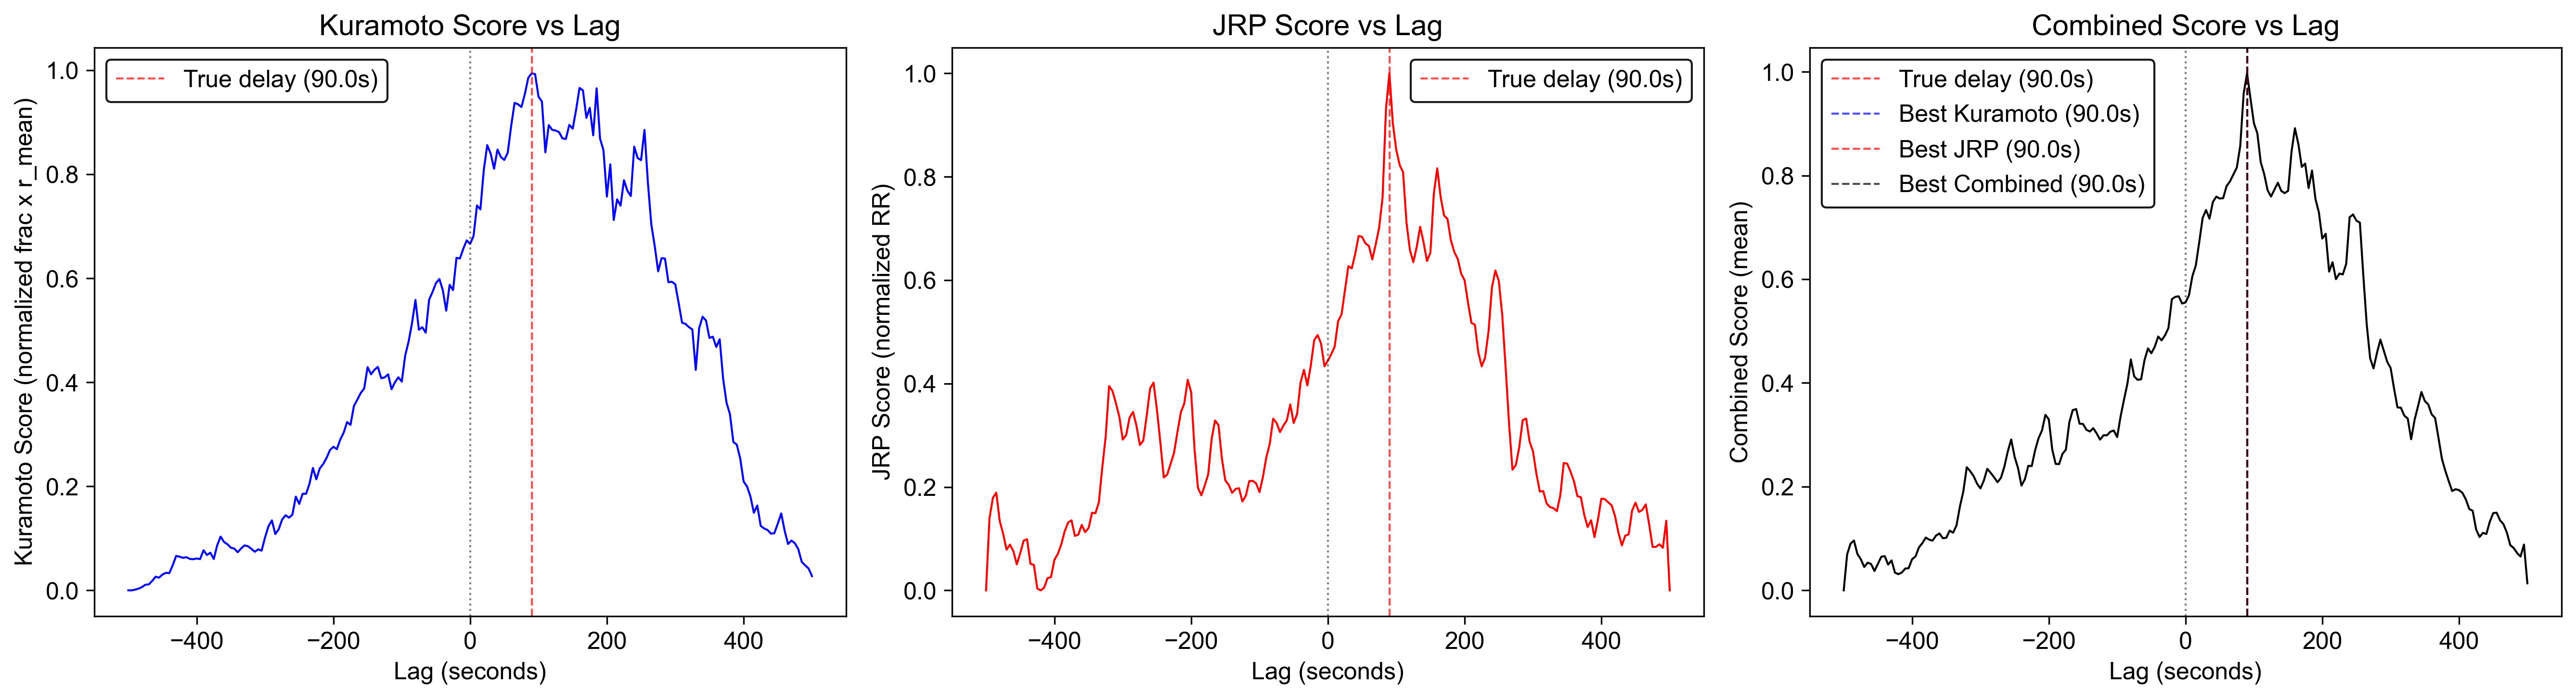

In [9]:
# Combined scores plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

axes[0].plot(results_df['lag_tu'], results_df['kuramoto_score'], 'b-', linewidth=1)
axes[0].set_xlabel('Lag (seconds)')
axes[0].set_ylabel('Kuramoto Score (normalized frac x r_mean)')
axes[0].set_title('Kuramoto Score vs Lag')
axes[0].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[0].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[0].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[1].plot(jrp_df['lag_tu'], jrp_df['jrp_score'], 'r-', linewidth=1)
axes[1].set_xlabel('Lag (seconds)')
axes[1].set_ylabel('JRP Score (normalized RR)')
axes[1].set_title('JRP Score vs Lag')
axes[1].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[1].legend(frameon=True, framealpha=0.9, edgecolor='black')

axes[2].plot(results_df['lag_tu'], results_df['combined_score'], 'k-', linewidth=1)
axes[2].set_xlabel('Lag (seconds)')
axes[2].set_ylabel('Combined Score (mean)')
axes[2].set_title('Combined Score vs Lag')
axes[2].axvline(x=0, color='k', linestyle=':', alpha=0.5)
axes[2].axvline(x=true_delay_sec, color='r', linestyle='--', alpha=0.7, label=f'True delay ({true_delay_sec:.1f}s)')
axes[2].axvline(x=best_kuramoto/sr, color='b', linestyle='--', alpha=0.7, label=f'Best Kuramoto ({best_kuramoto/sr:.1f}s)')
axes[2].axvline(x=best_jrp/sr, color='r', linestyle='--', alpha=0.7, label=f'Best JRP ({best_jrp/sr:.1f}s)')
axes[2].axvline(x=best_combined/sr, color='k', linestyle='--', alpha=0.7, label=f'Best Combined ({best_combined/sr:.1f}s)')
axes[2].legend(frameon=True, framealpha=0.9, edgecolor='black')

plt.tight_layout()
plt.show()

## Export Results

In [10]:
# Export all results
pipeline.export_results("results/industrial_pipeline")

Results exported to results/industrial_pipeline/


## Top 10 Results

In [11]:
# Top 10 results
print('=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===')
print(results_df.nlargest(10, 'kuramoto_score')[['lag_tu', 'r_mean', 'frac_above_07', 'max_sustained_tu', 'kuramoto_score']].to_string(index=False))

print('\n=== Top 10 by JRP Score (RR only, excl. extreme lags) ===')
print(jrp_valid.nlargest(10, 'jrp_score')[['lag_tu', 'jrp_RR', 'jrp_DET', 'jrp_LAM', 'jrp_score']].to_string(index=False))

=== Top 10 by Kuramoto Score (frac_above_07 x r_mean) ===
 lag_tu   r_mean  frac_above_07  max_sustained_tu  kuramoto_score
   90.0 0.837718       0.815680              74.0        0.994094
   95.0 0.835748       0.818182              98.0        0.992641
   85.0 0.836399       0.814012              56.0        0.985278
  160.0 0.833261       0.810676              98.0        0.965930
  185.0 0.829927       0.815680              98.0        0.965161
  165.0 0.829343       0.814846              98.0        0.961086
   80.0 0.828491       0.813178              56.0        0.954125
  100.0 0.829739       0.809008              98.0        0.949184
  105.0 0.832445       0.800667              98.0        0.939778
   65.0 0.824403       0.812344              57.0        0.937165

=== Top 10 by JRP Score (RR only, excl. extreme lags) ===
 lag_tu   jrp_RR  jrp_DET  jrp_LAM  jrp_score
   90.0 0.133970 0.986007 0.992957   1.000000
   85.0 0.131029 0.986279 0.993028   0.931033
   95.0 0.129867 0.